[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-uncover-highz-candidate-census/notebook.ipynb)

# How stable is the UNCOVER z >= 6 candidate count to redshift-posterior width?

**Scientific question:** How many quality-flagged candidates remain when the redshift posterior must be narrow?


This notebook uses the frozen UNCOVER DR3 “SUPER” photometric catalogue for
Abell 2744. The release combines HST and JWST imaging, detects sources in a
noise-equalized F277W+F356W+F444W image, PSF-matches the photometry to F444W,
and supplies EAzY photometric-redshift posteriors. The compact repository table
contains rows with usable photometry, a passing EAzY flag, and a maximum-
likelihood redshift from 6 to 15.

That is a candidate selection, not a confirmation list. A photometric redshift
can confuse a Lyman break with dust, an emission-line boosted band, or a lower-
redshift spectral break. Abell 2744 also lenses the background and changes both
the observed brightness and the effective source-plane area. Every result below
is therefore conditional on the release photometry, templates, flags, and lens
model. The notebook measures the catalogue; it does not claim a new population
measurement or spectroscopic discovery.

## Reproducibility contract

The source is Zenodo DOI `10.5281/zenodo.11059273`, retrieved on 1 August 2026.
The upstream FITS MD5 is `baeb44ce166c920050ceb93220b12e05`. The repository
derivative preserves coordinates, broad-band fluxes and errors, redshift
posterior percentiles, flags, an image size proxy, and lensing magnification.
Fluxes are in the catalogue's native 10 nJy units (AB zeropoint 28.9). We keep
negative flux measurements when summarising stacks because clipping them would
bias faint measurements upward. Each figure is saved at publication-oriented
resolution with SciencePlots' `science` style and `no-latex` for reliable Colab
execution.

## Claim boundary

The analysis distinguishes observed quantities from derived proxies. It reports
sample sizes, selection changes, resampling intervals, or parameter stress
tests. Results may motivate a targeted check against UNCOVER DR4 spectroscopy,
but the photometric catalogue alone cannot prove a galaxy's redshift, stellar
mass, star-formation rate, chemical abundance, or physical size. Those require
spectroscopy and/or more complete forward modelling with selection functions.

## Why this test matters

Raw counts at extreme photometric redshift can look impressive while being
dominated by broad or multi-modal posteriors. We use the central 68% width,
`z840-z160`, as a transparent—not definitive—precision diagnostic. Thresholds
from 1 to 5 are applied to the same 4,731-row table. A bootstrap interval for
the median redshift describes sampling stability inside the width<2 subset;
it does not include template or calibration systematics. The most important
output is the selection curve, because it shows how much the headline count
depends on a defensible but subjective quality boundary.

In [1]:
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220, "axes.titleweight": "bold"})
COLORS = {"navy": "#071426", "cyan": "#39c6d4", "gold": "#e3a82b",
          "coral": "#e66b55", "violet": "#7357c7", "green": "#3b9b77"}
RNG = np.random.default_rng(1999)

In [2]:
LOCAL = Path("../../data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv")
RAW = "https://raw.githubusercontent.com/Biswajit1999/daily-astro-notebooks/master/data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv"
if not LOCAL.exists():
    LOCAL = Path("uncover_dr3_z6_candidates.csv")
    if not LOCAL.exists():
        urllib.request.urlretrieve(RAW, LOCAL)
data = pd.read_csv(LOCAL)
print(f"Loaded {len(data):,} quality-flagged photometric candidates")
print(f"Sky footprint: RA {data.ra.min():.4f}–{data.ra.max():.4f} deg; Dec {data.dec.min():.4f}–{data.dec.max():.4f} deg")

Loaded 4,731 quality-flagged photometric candidates
Sky footprint: RA 3.4448–3.6699 deg; Dec -30.4673–-30.2914 deg


In [3]:
width = data.z840 - data.z160
finite = np.isfinite(width) & (width >= 0)
thresholds = np.array([1, 1.5, 2, 3, 4, 5, 7.5, 10])
counts = np.array([(finite & (width < value)).sum() for value in thresholds])
sensitivity = pd.DataFrame({"maximum_68pct_width": thresholds, "candidate_count": counts,
                            "fraction_of_flagged_table": counts / len(data)})
sensitivity.to_csv("selection_sensitivity.csv", index=False)
print(sensitivity.to_string(index=False))

 maximum_68pct_width  candidate_count  fraction_of_flagged_table
                 1.0              897                   0.189601
                 1.5             1063                   0.224688
                 2.0             1207                   0.255126
                 3.0             1428                   0.301839
                 4.0             1537                   0.324878
                 5.0             1670                   0.352991
                 7.5             2815                   0.595012
                10.0             3501                   0.740013


In [4]:
strict = data.loc[finite & (width < 2)].copy()
boot = np.array([np.median(RNG.choice(strict.z_phot, len(strict), replace=True)) for _ in range(2000)])
ci = np.percentile(boot, [2.5, 50, 97.5])
print(f"Width < 2: {len(strict):,} candidates; median z={np.median(strict.z_phot):.3f}")
print(f"Bootstrap 95% interval for median z: {ci[0]:.3f}–{ci[2]:.3f}")

Width < 2: 1,207 candidates; median z=6.778
Bootstrap 95% interval for median z: 6.743–6.886


## Distribution view

The filled histogram is the full quality-flagged table; the outline is the
narrow-posterior subset. Counts above roughly z=10 should receive extra
scrutiny because fewer filters lie redward of the break, selection volumes are
small, and low-redshift alternatives can remain. The plot is a catalogue
diagnostic, not a luminosity function: no completeness or source-plane area
correction has been applied.

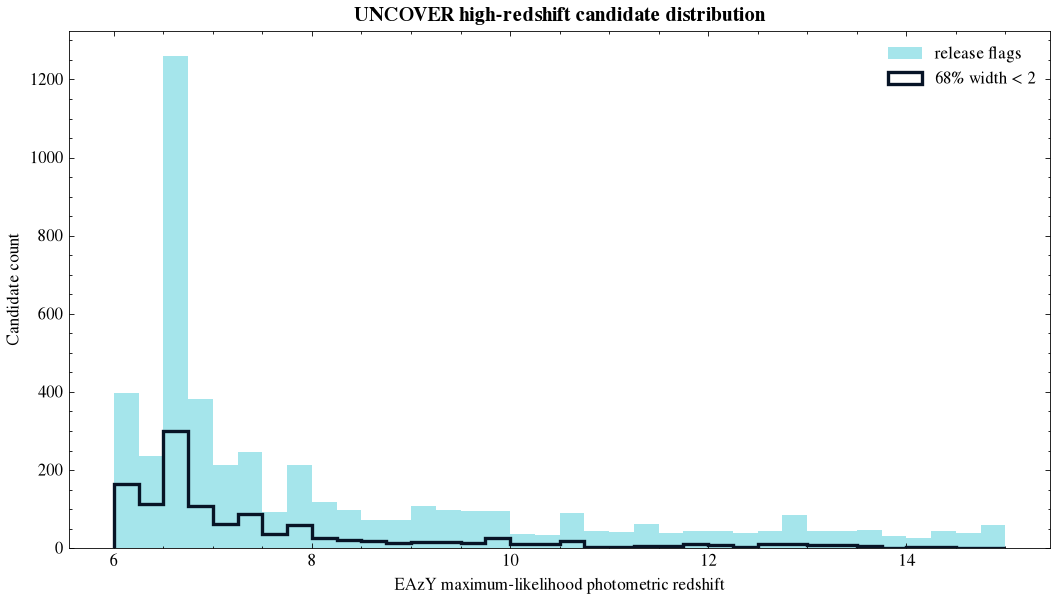

In [5]:
bins = np.arange(6, 15.25, .25)
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.hist(data.z_phot, bins=bins, color=COLORS["cyan"], alpha=.45, label="release flags")
ax.hist(strict.z_phot, bins=bins, histtype="step", color=COLORS["navy"], lw=2, label="68% width < 2")
ax.set(xlabel="EAzY maximum-likelihood photometric redshift", ylabel="Candidate count",
       title="UNCOVER high-redshift candidate distribution")
ax.legend(); fig.tight_layout(); fig.savefig("highz_redshift_distribution.png"); plt.show()

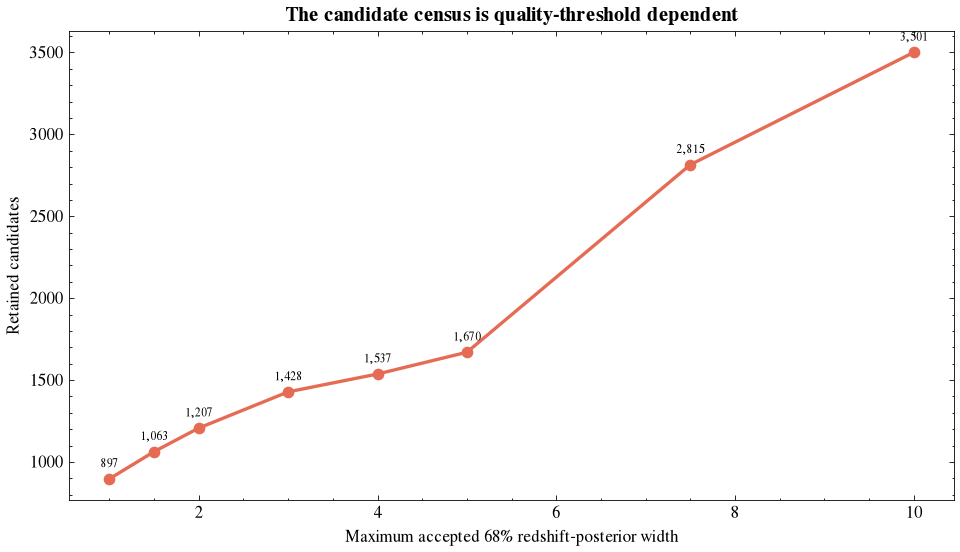

In [6]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(thresholds, counts, "o-", color=COLORS["coral"], lw=2)
for x, y in zip(thresholds, counts): ax.annotate(f"{y:,}", (x, y), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=7)
ax.set(xlabel="Maximum accepted 68% redshift-posterior width", ylabel="Retained candidates",
       title="The candidate census is quality-threshold dependent")
fig.tight_layout(); fig.savefig("posterior_width_sensitivity.png"); plt.show()

In [7]:
FOLDER="2026-08-01-uncover-highz-candidate-census"; TITLE="How stable is the UNCOVER z >= 6 candidate count?"
QUESTION="How many quality-flagged candidates remain when the redshift posterior must be narrow?"
SAMPLE_SIZE=len(data); RESULTS=[f"{len(strict):,} of {len(data):,} candidates have 68% posterior width < 2",
f"Strict-sample median z = {np.median(strict.z_phot):.2f} (bootstrap 95% {ci[0]:.2f}–{ci[2]:.2f})"]
VALIDATION="The sensitivity curve is the validation: the reported census is not treated as threshold-free."
FIGURES=["highz_redshift_distribution.png","posterior_width_sensitivity.png"]; ARTIFACTS=["selection_sensitivity.csv"]
QUALITY_CHECKS=[{"name":"release photometry flag","status":"passed"},{"name":"EAzY reliability flag","status":"passed"},{"name":"posterior-width stress test","status":"passed"}]
LIMITATIONS=["Photometric candidates are not spectroscopic confirmations.","No completeness or lensing-area correction is applied."]

## References and next validation

- Suess et al. (2024), UNCOVER Data Release 3 photometric catalogue.
- Weaver et al. (2024), MegaScience and UNCOVER imaging catalogue methods.
- Bezanson et al. (2024), UNCOVER survey design and public data.
- Furtak et al. (2023), Abell 2744 lens model.
- Price et al. (2025), UNCOVER DR4/4.1 NIRSpec spectra and secure redshifts.

UNCOVER DR4.1 reports 409 secure or solid spectroscopic redshifts among 553
reduced targets and provides an updated v2.0 lens model. A strong follow-up is
to row-match the DR3 IDs to those products, remeasure the photometric-redshift
outlier rate, and replace approximate lens corrections used here. The notebook
is deliberately frozen to one internally consistent public photometric release
so that later comparisons are explicit rather than silently mixing versions.

In [8]:
record = {
    "id": FOLDER,
    "title": TITLE,
    "archive": "UNCOVER / MAST",
    "date": "2026-08-01",
    "question": QUESTION,
    "sample_size": int(SAMPLE_SIZE),
    "results": RESULTS,
    "validation": VALIDATION,
    "notebook": f"mast/{FOLDER}/notebook.ipynb",
    "hero": f"mast/{FOLDER}/{FIGURES[0]}",
    "figures": [f"mast/{FOLDER}/{name}" for name in FIGURES],
    "research_level": "Exploration",
    "claim_type": "Photometric candidate analysis",
    "provenance": [
        "UNCOVER DR3 SUPER catalog, Zenodo DOI 10.5281/zenodo.11059273",
        "Upstream MD5 baeb44ce166c920050ceb93220b12e05",
        "Selection: use_phot=1, flag_eazy=1, 6 <= z_phot < 15",
    ],
    "artifacts": [f"mast/{FOLDER}/{name}" for name in ARTIFACTS],
    "quality_checks": QUALITY_CHECKS,
    "limitations": LIMITATIONS,
}
Path("result.json").write_text(json.dumps(record, indent=2) + "\n")
print("Saved machine-readable scientific audit:", Path("result.json").resolve())

Saved machine-readable scientific audit: /workspace/scratch/20efe8222c82/daily-astro-stage9/mast/2026-08-01-uncover-highz-candidate-census/result.json
